## 선형 회귀

### k-최근접 이웃의 한계

In [2]:
import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [3]:
# 데이터 나누기
# 특성 데이터는 2차원 배열로 변환
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

# 특성 데이터는 2차원 배열로 변환
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [4]:
# 최근접 이웃 개수를 3으로 설정
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)

# 모델 훈련
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [5]:
# 길이가 50cm인 농어에 대한 무게 예측
knr.predict([[50]])

array([1033.33333333])

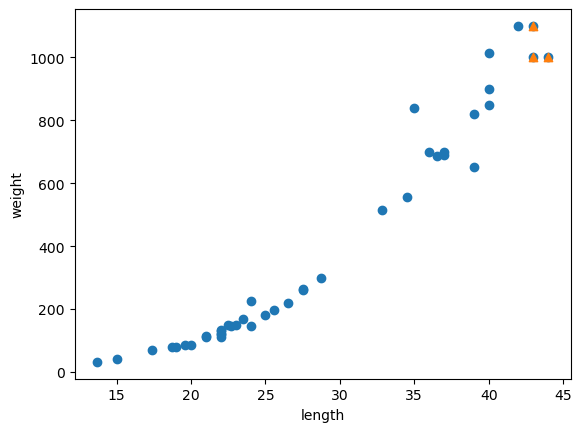

In [6]:
# 산점도 표시
import matplotlib.pyplot as plt

# 50 농어의 이웃 구하기
distances, indexes = knr.kneighbors([[50]])

# 훈련 세트의 산점도 그리기
plt.scatter(train_input, train_target)

# 이웃 샘플만 표시
plt.scatter(train_input[indexes], train_target[indexes], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [7]:
# 샘플들의 무게 평균 구하기
# 이웃 샘플의 타깃의 평균 구하기
print(np.mean(train_target[indexes]))

1033.3333333333333


- k-최근접 이웃 회귀는 가장 가까운 샘플을 찾아 타깃을 평균함

- 새로운 샘플이 훈련 세트의 범위를 벗어나면 엉뚱한 값을 예측할 수 있음

In [8]:
# 예를 들어 길이가 100인 농어도 여전히 1033g으로 예측할 수 있음
print(knr.predict([[100]]))

[1033.33333333]


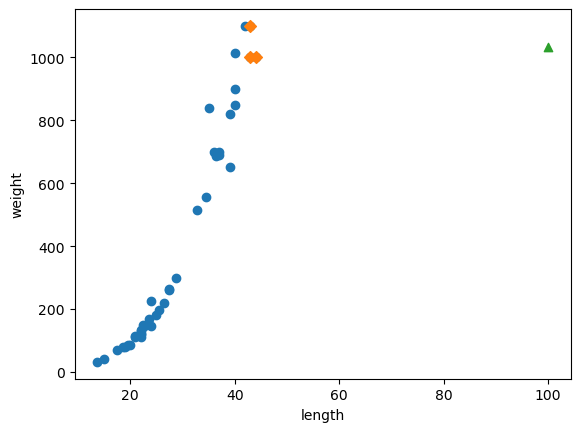

In [9]:
# 그래프 확인

# 100 농어의 이웃 구하기
distances, indexes = knr.kneighbors([[100]])

# 훈련 세트의 산점도 그리기
plt.scatter(train_input, train_target)

# 이웃 샘플만 표시
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 100 농어 표시
plt.scatter(100, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

- 머신러닝 모델은 한 번 만들고 끝나는 프로그램이 아님

- 시간과 환경이 변화하면서 데이터도 바뀌기 때문에 주기적으로 새로운 훈련 데이터로 모델을 다시 훈련해야 함

### 선형 회귀

선형 회귀(liner regression)
- 비교적 간단하고 성능이 뛰어난 회귀 알고리즘

- 특성이 하나인 경우 어떤 직선을 학습하는 알고리즘
- 특성을 가장 잘 나타낼 수 있는 직선을 찾아야 함!

- 사이킷런은 sklearn.linear_model 패키지 아래에 LimearRegression 클래스로 선형 회위 알고리즘을 구현함

- LinearRegression 클래스에도 fit(), score(), predicr() 메서드가 있음

In [10]:
from sklearn.linear_model import LinearRegression

# 선형 회귀 모델 객체 만들기
lr = LinearRegression()

# 모델 훈련
lr.fit(train_input, train_target)

# 길이가 50cm인 농어에 대한 무게 예측
print(lr.predict([[50]]))

[1241.83860323]


- 하나의 직선을 그리려면 기울기와 절편이 있어야 함

- y = a * x + b

- LinearRegression 클래스가 이 데이터에 가장 잘 맞는 a와 b를 찾음

- 찾은 a와 b는 lr 객체의 coef_와 intercept_ 속성에 저장

In [11]:
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535474


- coef_와 intercept_를 머신러닝 알고리즘이 찾은 값이라는 의미로 모델 파라미터(model parameter)라고 부름

- 머신러닝 알고리즘의 훈련 과정은 최적의 모델 파라미터를 찾는 것과 같음
- 이를 '모델 기반 학습'이라 부름
- k-최근접 이웃에는 모델 파라미터가 없음
- 훈련 세트를 저장하는 것이 훈련의 전부 -> '사례 기반 학습'

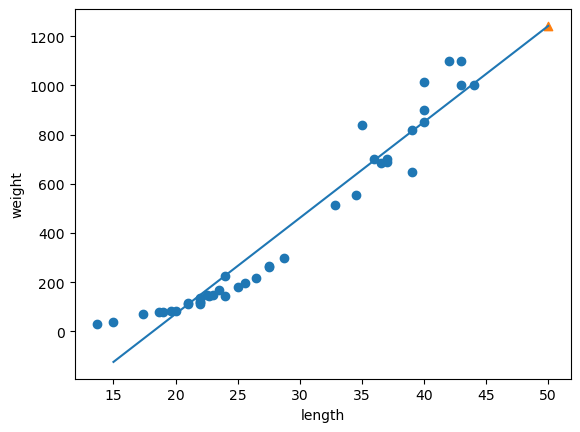

In [12]:
# 훈련 세트의 산점도 그리기
plt.scatter(train_input, train_target)

# 15에서 50까지 1차 방정식 그래프 그리기
plt.plot([15, 50], [15*lr.coef_ + lr.intercept_, 50*lr.coef_ + lr.intercept_])

# 50 농어 표시
plt.scatter(50, 1241, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

- 이 직선이 선형 회위 알고리즘이 이 데이터셋에서 찾은 최적의 직선

In [13]:
# 훈련 세트와 테스트 세트에 대한 R^2 점수 구하기
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.9398463339976041
0.824750312331356


### 다항 회귀

- 2차 방적식의 그래프를 그리려면 길이를 제곱한 항이 훈련 세트에 추가되어야 함

- column_stack() 함수를 사용하면 간단히 구현 가능

- train_input을 제곱한 것과 train_input 두 배열을 나란히 붙이면 됨

In [14]:
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

- train_input ** 2 식에도 넘파이 브로트캐스팅이 적용됨

- train_input에 있는 모든 원소를 제곱함

In [15]:
# 데이터셋 크기 확인
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


- 원래 특성인 길이를 제곱하여 왼쪽 열에 추가했기 때문에 훈련 세트와 테스트 세트 모두 열이 2개로 늘어남

- train_poly를 사용해 선형 회귀 모델 다시 훈련

- 이 모델이 2차 방정식의 a, b, c를 잘 찾을 것으로 기대
- 2차 방정식 그래프를 찾기 위해 훈련 세트에 제곱 항을 추가했지만, 타겟값은 그대로 사용
- 목표하는 값은 어떤 그래프를 훈련 하든지 바꿀 필요 없음
- 테스트할 때는 이 모델에 농어 길이의 제곱과 원래 길이를 함께 넣어줘야 함

In [16]:
lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.predict([[50**2, 50]]))

[1573.98423528]


In [17]:
# 훈련한 계수와 절편 출력
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.05021078278338


- 모델은 다음과 같은 그래프를 학습

- 무게 = 1.01 * 길이^2 - 21.6 * 길이 + 116.05

- 이런 방정식을 다항식(polynomial)이라 부름

- 다항식을 사용한 선형 회귀를 다항 회귀(polynomial regression)라 함

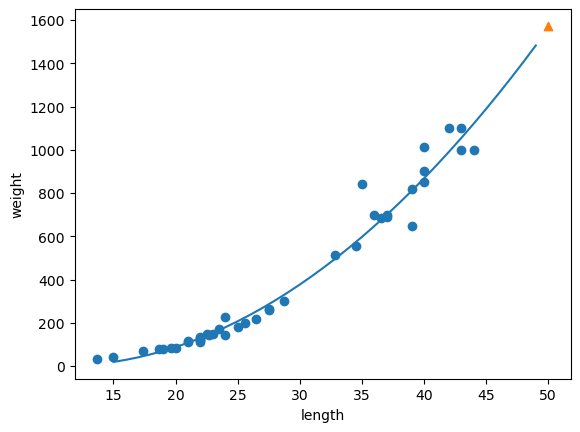

In [18]:
# 산점도 표시

# 구간별 직선을 그리기 위해 15에서 49까지 정수 배열 만들기
point = np.arange(15, 50)

# 훈련 세트의 산점도 그리기
plt.scatter(train_input, train_target)

# 15에서 49까지 2차 방정식 그래프 그리기
plt.plot(point, 1.01*point**2 - 21.6*point + 116.05)

# 50 농어 표시
plt.scatter(50, 1573, marker='^')
plt.xlabel('length')        
plt.ylabel('weight')
plt.show()